## Run locally - news data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path)

    # Convert 'date' column to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Sort data
    df = df.sort_values(by='date', ascending=True) 

    # Round up to the next minute
    df['date'] = df['date'].dt.ceil('min')

    # # Filter data for the year 2023
    # df = df[df['date'].dt.year == 2023]

    # Drop columns
    df = df.drop(columns=['text'])

    # Set index
    df.set_index('date', inplace=True)

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/3.0/bitcoin_tweets_data.csv")

In [4]:
df

,sentiment_labels,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
date,,,,,
2021-02-05 10:53:00,Neutral,0.977616,0.000037,0.977616,0.022346
2021-02-05 10:53:00,Neutral,0.954292,0.000051,0.954292,0.045656
2021-02-05 10:53:00,Bullish,0.634788,0.000235,0.364977,0.634788
2021-02-05 10:53:00,Bullish,0.588202,0.000745,0.411053,0.588202
2021-02-05 10:53:00,Bullish,0.742979,0.002413,0.254608,0.742979
...,...,...,...,...,...
2021-08-21 12:59:00,Bullish,0.502171,0.000291,0.497538,0.502171
2021-08-21 12:59:00,Neutral,0.880053,0.009635,0.880053,0.110313
2021-08-21 12:59:00,Bullish,0.756113,0.000089,0.243798,0.756113


In [5]:
df.isna().sum()

sentiment_labels          0
sentiment_confidence      0
sentiment_prob_class_0    0
sentiment_prob_class_1    0
sentiment_prob_class_2    0
dtype: int64

In [6]:
df.describe()

,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
count,999981.000000,999981.000000,999981.000000,999981.000000
mean,0.697805,0.045360,0.532415,0.422225
std,0.142663,0.161215,0.246367,0.246413
min,0.333994,0.000025,0.002077,0.000405
25%,0.581922,0.000183,0.336237,0.218257
50%,0.677323,0.000552,0.508222,0.440271
75%,0.795754,0.003449,0.715264,0.627442
max,0.998145,0.997162,0.998145,0.984830


In [7]:
# # Map the sentiment values to the corresponding sentiment
# df['Sentiment_Labels'] = df['Accurate Sentiments'].map(lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral')
# df.head()

In [8]:
sentiment_counts = df['sentiment_labels'].value_counts()
print(sentiment_counts)

sentiment_labels
Neutral    522395
Bullish    431924
Bearish     45662
Name: count, dtype: int64


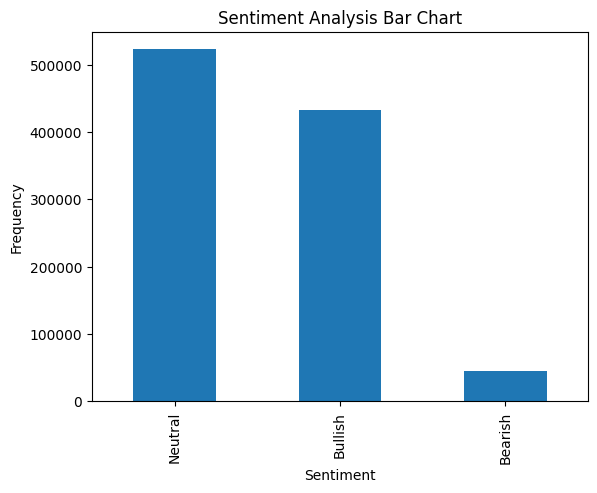

In [9]:
df['sentiment_labels'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis Bar Chart')
plt.xlabel('Sentiment')
plt.ylabel('Frequency');

In [10]:
# df[:100:].plot(y='Accurate Sentiments');

In [11]:
# # Save the cleaned data
# df.to_csv('/Users/alexzheng/Developer/GitHub/EC331-project/data/3.0/bitcoin_scores.csv')

### Create Sentiment Scores (Polarity) between -1 and 1

In [12]:
# Given "class_2" is positive sentiment and "class_0" is negative sentiment

# Map the sentiment_labels column to numerical values
df['sentiment_numeric'] = df['sentiment_labels'].map({'Bullish': 1, 'Neutral': 0, 'Bearish': -1})

# Compute weighted sentiment score using 'sentiment_numeric' and 'sentiment_confidence'
df['sentiment_score'] = df['sentiment_numeric'] * df['sentiment_confidence']

# Group by rounded-up hour, and create a new df with the weighted mean of sentiment scores
# Articles with high confidence should have a bigger impact
df_score = df.groupby(df.index).apply(
    lambda x: (x['sentiment_score'] * x['sentiment_confidence']).sum() / x['sentiment_confidence'].sum()
)

# Convert Series to DataFrame
df_score = df_score.to_frame(name='weighted_sentiment_score')

# Display the cleaned DataFrame
df_score

,weighted_sentiment_score
date,
2021-02-05 10:53:00,0.333760
2021-02-05 10:54:00,0.000000
2021-02-05 10:55:00,0.591740
2021-02-05 10:58:00,-0.465576
2021-02-05 10:59:00,0.457929
...,...
2021-08-21 12:55:00,0.330864
2021-08-21 12:56:00,0.345120
2021-08-21 12:57:00,0.183834


In [13]:
# # Filter data for dates after 2024
# df_filtered = df_score[df_score.index >= '2024-01-01']

# # Plot sentiment scores
# plt.figure(figsize=(10, 6))
# plt.plot(df_filtered.index, df_filtered['weighted_sentiment_score'])
# plt.title('Sentiment Score Time Series')
# plt.xlabel('Date')
# plt.ylabel('Sentiment Score')
# plt.show()

In [14]:
df_score.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/3.0/NEW_bitcoin_scores.csv")